# Modelos separados por entorno y con filtros

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt  
import seaborn as sns
import warnings

from sklearn.preprocessing import MinMaxScaler, LabelEncoder, OneHotEncoder, PowerTransformer, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsRegressor
from sklearn import neighbors
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_squared_log_error, r2_score, explained_variance_score, root_mean_squared_error

import scipy.stats as stats
from scipy.stats import kurtosis, boxcox

import mglearn
import matplotlib

warnings.filterwarnings('ignore')

In [2]:
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
from xgboost import XGBRegressor
from sklearn.svm import SVR
from sklearn.ensemble import StackingRegressor
from sklearn.ensemble import GradientBoostingRegressor, ExtraTreesRegressor, AdaBoostRegressor
import lightgbm as lgb
from sklearn.linear_model import HuberRegressor, BayesianRidge, QuantileRegressor, TheilSenRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.experimental import enable_hist_gradient_boosting  # noqa
from sklearn.ensemble import HistGradientBoostingRegressor
from catboost import CatBoostRegressor
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel
from sklearn.multioutput import MultiOutputRegressor


In [3]:
df= pd.read_excel('C:/Users/elias/OneDrive/Desktop/MachineLearning/MLProject/CopiaDataBaseSGC.xlsx')

In [4]:
df.drop(["Record Sequence Number"], axis=1, inplace=True)
df.drop(["Station ID"], axis=1, inplace=True)
df.drop(["Station Code"], axis=1, inplace=True)
df.drop(["Magnitude type"], axis=1, inplace=True)
df.drop(["EQID"], axis=1, inplace=True)
df.drop(["Valor_T1.5"], axis=1, inplace=True)
df.drop(["Tmax"], axis=1, inplace=True)
df.drop(["Epicenter Latitude (deg; positive N)"], axis=1, inplace=True)
df.drop(["Epicenter Longitude (deg; positive E)"], axis=1, inplace=True)
df.drop(["Station Latitude (deg positive N)"], axis=1, inplace=True)
df.drop(["Station Longitude (deg positive E)"], axis=1, inplace=True)
df.drop(["Topografía"], axis=1, inplace=True)
df.drop(["Geología"], axis=1, inplace=True)
df.drop(["Nodal Plane 1 Rake Angle (deg)"], axis=1, inplace=True)
df.drop(["Nodal Plane 2 Rake Angle (deg)"], axis=1, inplace=True)
df.drop(["Nodal Plane 2 Dip (deg)"], axis=1, inplace=True)
df.drop(["Nodal Plane 2 Strike (deg)"], axis=1, inplace=True)
df.drop(["Rx_OpenQuake"], axis=1, inplace=True)
df.drop(["Ry0_OpenQuake"], axis=1, inplace=True)
df.drop(["Rjb_OpenQuake"], axis=1, inplace=True)
#df.drop(["Rrup_OpenQuake"], axis=1, inplace=True)
df.drop(["Repi_OpenQuake"], axis=1, inplace=True)
#df.drop(["Rhypo_OpenQuake"], axis=1, inplace=True)
df.drop(["Station Elevation (m)"], axis=1, inplace=True)
df.drop(["Soil_Class"], axis=1, inplace=True)
df.drop(["Nodal Plane 1 Strike (deg)"], axis=1, inplace=True)
df.drop(["Nodal Plane 1 Dip (deg)"], axis=1, inplace=True)
df.drop(["Fault Plane (1; 2; X)"], axis=1, inplace=True)
df.drop(["Style-of-Faulting (S; R; N; U)"], axis=1, inplace=True)

In [5]:
#df = df.iloc[:, :df.columns.get_loc("T_0.01_RotD50") + 1]

In [6]:
df_copy = df.copy()

In [7]:
#df_copy["T_0.01_RotD50"]= np.log(df_copy["T_0.01_RotD50"])
#df_copy["Rhypo_OpenQuake"]= np.log(df_copy["Rhypo_OpenQuake"])

In [8]:
df_crustal = df_copy[df_copy['Tectonic environment (Crustal; Inslab; Interface; Stable; Deep; Volcanic; Oceanic_crust)'] == 'Crustal'].copy()
df_subduction = df[df['Tectonic environment (Crustal; Inslab; Interface; Stable; Deep; Volcanic; Oceanic_crust)'].isin(['Inslab', 'Interface'])].copy()
df_deep = df_copy[df_copy['Tectonic environment (Crustal; Inslab; Interface; Stable; Deep; Volcanic; Oceanic_crust)'] == 'Deep'].copy()

In [9]:
df_crustal

,Hypocenter Depth (km),Magnitude,Tectonic environment (Crustal; Inslab; Interface; Stable; Deep; Volcanic; Oceanic_crust),Tn,Rrup_OpenQuake,Rhypo_OpenQuake,T_0.01_RotD50,T_0.02_RotD50,T_0.03_RotD50,T_0.04_RotD50,...,T_2.5_RotD50,T_3.0_RotD50,T_4.0_RotD50,T_5.0_RotD50,T_6.0_RotD50,T_7.0_RotD50,T_7.5_RotD50,T_8.0_RotD50,T_9.0_RotD50,T_10.0_RotD50
0,14.7,5.8671,Crustal,0.24,86.623229,93.551751,4.755494,4.800657,4.892163,5.042099,...,3.343425,2.299123,1.315019,1.234997,1.237165,0.987941,0.743912,0.636538,0.507903,0.401487
1,33.1,5.0567,Crustal,0.24,99.461616,102.497369,10.887828,11.126960,11.962335,14.795546,...,0.315437,0.146246,0.076441,0.056793,0.040160,0.027227,0.022587,0.018555,0.014793,0.012429
2,14.0,6.0202,Crustal,0.16,174.684394,181.353681,4.847060,4.911509,5.065576,5.246479,...,1.708121,0.888446,0.410937,0.252350,0.162552,0.115164,0.098742,0.085727,0.066178,0.053164
3,14.0,6.2562,Crustal,0.16,244.405678,254.752031,1.814338,1.952437,2.083609,1.984019,...,0.230457,0.136652,0.127038,0.090174,0.049763,0.032587,0.027046,0.020240,0.014986,0.012210
4,17.0,6.1355,Crustal,0.16,135.354859,141.709990,9.462926,9.622603,9.635580,10.581168,...,1.166125,0.831870,0.424420,0.296639,0.202097,0.176231,0.155668,0.147029,0.163535,0.134796
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4620,15.0,4.3000,Crustal,0.50,296.031423,297.445289,0.403902,0.407545,0.412280,0.418098,...,0.018411,0.012810,0.006135,0.003363,0.002155,0.002217,0.002157,0.001951,0.002047,0.001687
4621,16.0,4.0000,Crustal,0.50,295.931516,296.611856,0.208088,0.210143,0.210303,0.213729,...,0.008297,0.005641,0.003159,0.001720,0.001208,0.000880,0.000797,0.000832,0.000692,0.000637
4622,16.0,4.4000,Crustal,0.50,296.180748,297.506537,0.685194,0.686584,0.690435,0.696905,...,0.043865,0.026151,0.013874,0.008528,0.005441,0.004235,0.003670,0.003186,0.002827,0.002370
4623,4.0,5.1000,Crustal,0.50,719.316553,722.527004,0.046228,0.116454,0.138176,0.098851,...,0.018875,0.011364,0.008718,0.004197,0.002960,0.004321,0.004058,0.003591,0.003558,0.003089


In [10]:
df_subduction

,Hypocenter Depth (km),Magnitude,Tectonic environment (Crustal; Inslab; Interface; Stable; Deep; Volcanic; Oceanic_crust),Tn,Rrup_OpenQuake,Rhypo_OpenQuake,T_0.01_RotD50,T_0.02_RotD50,T_0.03_RotD50,T_0.04_RotD50,...,T_2.5_RotD50,T_3.0_RotD50,T_4.0_RotD50,T_5.0_RotD50,T_6.0_RotD50,T_7.0_RotD50,T_7.5_RotD50,T_8.0_RotD50,T_9.0_RotD50,T_10.0_RotD50
6565,178.0,6.3362,Inslab,0.24,228.621778,241.727647,2.390327,2.448996,2.551538,2.728272,...,0.046891,0.028735,0.015313,0.010000,0.007254,0.005620,0.004779,0.004211,0.003409,0.002781
6566,120.0,6.5251,Inslab,0.16,137.730823,150.015713,63.968883,64.787702,66.405512,70.138376,...,4.029374,2.495921,2.145986,1.666906,1.226747,0.939381,0.801422,0.668689,0.510683,0.411196
6567,109.0,5.2969,Inslab,0.16,208.339511,210.496422,3.302280,3.600635,3.415243,3.622899,...,0.181359,0.172852,0.108003,0.052255,0.055582,0.035405,0.033644,0.026809,0.017548,0.013713
6568,103.3,5.7756,Inslab,0.16,174.665150,181.726204,12.216639,12.525386,12.656565,13.714364,...,0.590518,0.368640,0.182975,0.094676,0.060026,0.043579,0.036037,0.031590,0.026432,0.020250
6569,206.0,6.7397,Inslab,0.16,289.922702,294.486478,10.392811,10.586116,10.564264,11.938985,...,1.215354,0.586775,0.331877,0.170280,0.110104,0.076829,0.065947,0.057004,0.044814,0.034682
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8806,5.0,5.6000,Interface,0.50,1230.049890,1236.043904,0.004725,0.008197,0.006540,0.005759,...,0.004976,0.005132,0.005019,0.004619,0.004156,0.004023,0.003972,0.004305,0.004837,0.004476
8807,10.0,5.0181,Interface,0.50,1248.234684,1253.495004,0.003128,0.008441,0.006622,0.008719,...,0.002363,0.002004,0.001086,0.000931,0.000823,0.000632,0.000696,0.000622,0.000673,0.000610
8808,47.0,5.0304,Interface,0.50,1209.579637,1217.416127,0.003101,0.008199,0.005089,0.004452,...,0.002001,0.001780,0.001028,0.001106,0.000691,0.000553,0.000531,0.000546,0.000463,0.000483
8809,10.0,5.0266,Interface,0.50,725.018483,729.171353,0.020313,0.080841,0.038791,0.046940,...,0.002233,0.002062,0.001421,0.001202,0.000882,0.000795,0.000703,0.000733,0.000629,0.000560


In [11]:
df_deep

,Hypocenter Depth (km),Magnitude,Tectonic environment (Crustal; Inslab; Interface; Stable; Deep; Volcanic; Oceanic_crust),Tn,Rrup_OpenQuake,Rhypo_OpenQuake,T_0.01_RotD50,T_0.02_RotD50,T_0.03_RotD50,T_0.04_RotD50,...,T_2.5_RotD50,T_3.0_RotD50,T_4.0_RotD50,T_5.0_RotD50,T_6.0_RotD50,T_7.0_RotD50,T_7.5_RotD50,T_8.0_RotD50,T_9.0_RotD50,T_10.0_RotD50
4625,160.9,5.2943,Deep,0.24,336.403251,340.068350,2.824305,2.853066,2.887672,2.942054,...,0.177938,0.145786,0.080921,0.038289,0.024272,0.016960,0.014051,0.011623,0.009538,0.007932
4626,161.1,5.4046,Deep,0.24,332.763531,340.004092,3.090696,3.120594,3.177530,3.199094,...,0.287515,0.185111,0.093480,0.046516,0.029728,0.023065,0.020641,0.018569,0.014432,0.011837
4627,155.0,6.2492,Deep,0.24,325.574327,341.356272,11.454331,11.528240,11.684620,11.847215,...,1.333088,1.042788,0.467530,0.229266,0.133321,0.096438,0.083692,0.073329,0.056739,0.045196
4628,160.9,5.2943,Deep,0.16,378.127438,384.346199,1.508480,1.522253,1.545044,1.579676,...,0.053348,0.033402,0.017404,0.010972,0.008759,0.006749,0.006340,0.005672,0.004780,0.003613
4629,160.9,5.2943,Deep,0.12,387.041847,393.066224,1.075587,1.092522,1.107815,1.134858,...,0.076606,0.056582,0.028080,0.019548,0.013019,0.009359,0.007694,0.006340,0.004500,0.003365
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6560,152.0,4.6000,Deep,0.50,234.121790,236.038843,0.701221,0.704603,0.707515,0.718484,...,0.047471,0.025564,0.010800,0.007303,0.005129,0.003640,0.003029,0.002708,0.002122,0.001650
6561,143.0,4.6000,Deep,0.50,227.938463,231.026960,0.251664,0.254559,0.257574,0.265571,...,0.016890,0.009905,0.005023,0.002836,0.001853,0.001375,0.001143,0.001052,0.000887,0.000710
6562,126.0,4.9000,Deep,0.50,547.211357,553.688713,0.073324,0.074352,0.074431,0.076444,...,0.022858,0.012222,0.005732,0.003210,0.002213,0.001502,0.001402,0.001128,0.000949,0.000728
6563,153.0,5.2000,Deep,0.50,232.918431,236.422839,0.997223,1.016831,1.057104,1.163515,...,0.080847,0.045275,0.023259,0.014401,0.009592,0.006662,0.005845,0.005080,0.003934,0.002923


## Filtros

### Filtros Crustal

In [12]:
df_crustal = df_crustal[(df_crustal['Magnitude'] > 4.5) & (df_crustal['Magnitude'] < 6.8)]
df_crustal = df_crustal[(df_crustal['Rrup_OpenQuake'] > 13) & (df_crustal['Rrup_OpenQuake'] < 350)]

df_crustal = df_crustal[df_crustal['Hypocenter Depth (km)'] < 60]
df_crustal = df_crustal[df_crustal['Rrup_OpenQuake'] < 350]
df_crustal.reset_index(drop=True, inplace=True)

In [13]:
df_crustal

,Hypocenter Depth (km),Magnitude,Tectonic environment (Crustal; Inslab; Interface; Stable; Deep; Volcanic; Oceanic_crust),Tn,Rrup_OpenQuake,Rhypo_OpenQuake,T_0.01_RotD50,T_0.02_RotD50,T_0.03_RotD50,T_0.04_RotD50,...,T_2.5_RotD50,T_3.0_RotD50,T_4.0_RotD50,T_5.0_RotD50,T_6.0_RotD50,T_7.0_RotD50,T_7.5_RotD50,T_8.0_RotD50,T_9.0_RotD50,T_10.0_RotD50
0,14.7,5.8671,Crustal,0.24,86.623229,93.551751,4.755494,4.800657,4.892163,5.042099,...,3.343425,2.299123,1.315019,1.234997,1.237165,0.987941,0.743912,0.636538,0.507903,0.401487
1,33.1,5.0567,Crustal,0.24,99.461616,102.497369,10.887828,11.126960,11.962335,14.795546,...,0.315437,0.146246,0.076441,0.056793,0.040160,0.027227,0.022587,0.018555,0.014793,0.012429
2,14.0,6.0202,Crustal,0.16,174.684394,181.353681,4.847060,4.911509,5.065576,5.246479,...,1.708121,0.888446,0.410937,0.252350,0.162552,0.115164,0.098742,0.085727,0.066178,0.053164
3,14.0,6.2562,Crustal,0.16,244.405678,254.752031,1.814338,1.952437,2.083609,1.984019,...,0.230457,0.136652,0.127038,0.090174,0.049763,0.032587,0.027046,0.020240,0.014986,0.012210
4,17.0,6.1355,Crustal,0.16,135.354859,141.709990,9.462926,9.622603,9.635580,10.581168,...,1.166125,0.831870,0.424420,0.296639,0.202097,0.176231,0.155668,0.147029,0.163535,0.134796
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
968,47.8,4.8688,Crustal,0.50,329.481031,332.517301,0.619515,0.621042,0.623192,0.626090,...,0.067199,0.056573,0.026869,0.013040,0.009591,0.006127,0.005123,0.004132,0.003297,0.002804
969,10.0,5.9519,Crustal,0.50,271.235666,278.658461,8.794320,8.821259,8.872291,8.956253,...,1.527142,0.939965,0.528409,0.302801,0.251188,0.202516,0.191780,0.222371,0.204124,0.162766
970,10.0,5.7499,Crustal,0.50,282.579673,288.327721,4.401290,4.413655,4.434019,4.459130,...,0.831630,0.609809,0.305092,0.226591,0.165559,0.171955,0.180575,0.180707,0.137984,0.117232
971,10.0,4.7000,Crustal,0.50,293.340059,294.509089,2.084397,2.091699,2.110858,2.136673,...,0.095512,0.064818,0.030172,0.017779,0.013233,0.009312,0.009256,0.008168,0.006806,0.005521


### Filtros Inslab e Interface

In [14]:
#df_subduction["T_0.01_RotD50"] = np.exp(df_subduction["T_0.01_RotD50"])
df_subduction["T_0.01_RotD50"]= df_subduction["T_0.01_RotD50"]/980

In [15]:
df_subduction['T_0.01_RotD50'].min()

2.059001020408163e-06

In [16]:
df_subduction = df_subduction[df_subduction['T_0.01_RotD50'] > 0.0001]
df_subduction["T_0.01_RotD50"] = df_subduction["T_0.01_RotD50"]*980
#df_subduction["T_0.01_RotD50"] = np.log(df_subduction["T_0.01_RotD50"])

In [17]:
df_subduction = df_subduction[df_subduction['Rhypo_OpenQuake'] < 350]
df_subduction.reset_index(drop=True, inplace=True)

In [18]:
df_subduction

,Hypocenter Depth (km),Magnitude,Tectonic environment (Crustal; Inslab; Interface; Stable; Deep; Volcanic; Oceanic_crust),Tn,Rrup_OpenQuake,Rhypo_OpenQuake,T_0.01_RotD50,T_0.02_RotD50,T_0.03_RotD50,T_0.04_RotD50,...,T_2.5_RotD50,T_3.0_RotD50,T_4.0_RotD50,T_5.0_RotD50,T_6.0_RotD50,T_7.0_RotD50,T_7.5_RotD50,T_8.0_RotD50,T_9.0_RotD50,T_10.0_RotD50
0,178.0,6.3362,Inslab,0.24,228.621778,241.727647,2.390327,2.448996,2.551538,2.728272,...,0.046891,0.028735,0.015313,0.010000,0.007254,0.005620,0.004779,0.004211,0.003409,0.002781
1,120.0,6.5251,Inslab,0.16,137.730823,150.015713,63.968883,64.787702,66.405512,70.138376,...,4.029374,2.495921,2.145986,1.666906,1.226747,0.939381,0.801422,0.668689,0.510683,0.411196
2,109.0,5.2969,Inslab,0.16,208.339511,210.496422,3.302280,3.600635,3.415243,3.622899,...,0.181359,0.172852,0.108003,0.052255,0.055582,0.035405,0.033644,0.026809,0.017548,0.013713
3,103.3,5.7756,Inslab,0.16,174.665150,181.726204,12.216639,12.525386,12.656565,13.714364,...,0.590518,0.368640,0.182975,0.094676,0.060026,0.043579,0.036037,0.031590,0.026432,0.020250
4,206.0,6.7397,Inslab,0.16,289.922702,294.486478,10.392811,10.586116,10.564264,11.938985,...,1.215354,0.586775,0.331877,0.170280,0.110104,0.076829,0.065947,0.057004,0.044814,0.034682
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
872,10.0,4.8714,Interface,0.58,107.863119,110.834458,2.102708,2.118841,2.158411,2.190419,...,0.114037,0.064195,0.032697,0.021795,0.015691,0.012899,0.010649,0.008750,0.006420,0.005228
873,10.0,5.0266,Interface,0.58,308.828267,312.351016,0.124349,0.154077,0.149956,0.231048,...,0.001744,0.002344,0.001485,0.001550,0.001398,0.001320,0.001196,0.001077,0.001114,0.001186
874,20.0,4.7000,Interface,0.06,97.475827,99.316956,1.736866,2.016624,2.468569,3.289297,...,0.047219,0.032914,0.019453,0.012265,0.015324,0.013837,0.010681,0.007361,0.004970,0.003367
875,10.0,4.8714,Interface,0.25,272.751403,274.921125,0.213437,0.215051,0.216112,0.217389,...,0.009947,0.005816,0.002455,0.001750,0.001675,0.001608,0.001766,0.001631,0.001770,0.001843


## Modelos

In [19]:
df_crustal["Rrup_OpenQuake"]= np.log(df_crustal["Rrup_OpenQuake"])

In [20]:
df_crustal['Magnitude'].max()

6.7765

In [21]:
df_crustal.drop(["Rhypo_OpenQuake"], axis=1, inplace=True)
df_crustal.drop(["Tectonic environment (Crustal; Inslab; Interface; Stable; Deep; Volcanic; Oceanic_crust)"], axis=1, inplace=True)

In [22]:
Sa_Crustal1 = df_crustal.filter(regex="^T_.*_RotD50$").columns
Sa_Crustal = df_crustal.filter(regex="^T_.*_RotD50$").columns
"""Sa_Crustal = ['T_0.01_RotD50', 'T_0.02_RotD50', 'T_0.03_RotD50', 'T_0.04_RotD50',
       'T_0.05_RotD50','T_0.075_RotD50','T_0.1_RotD50','T_0.15_RotD50','T_0.2_RotD50','T_0.25_RotD50','T_0.3_RotD50',
        'T_0.4_RotD50','T_0.5_RotD50','T_0.75_RotD50','T_1.0_RotD50','T_1.5_RotD50','T_2.0_RotD50','T_3.0_RotD50',
        'T_4.0_RotD50','T_5.0_RotD50','T_6.0_RotD50','T_10.0_RotD50']"""
#Sa_Crustal


"Sa_Crustal = ['T_0.01_RotD50', 'T_0.02_RotD50', 'T_0.03_RotD50', 'T_0.04_RotD50',\n       'T_0.05_RotD50','T_0.075_RotD50','T_0.1_RotD50','T_0.15_RotD50','T_0.2_RotD50','T_0.25_RotD50','T_0.3_RotD50',\n        'T_0.4_RotD50','T_0.5_RotD50','T_0.75_RotD50','T_1.0_RotD50','T_1.5_RotD50','T_2.0_RotD50','T_3.0_RotD50',\n        'T_4.0_RotD50','T_5.0_RotD50','T_6.0_RotD50','T_10.0_RotD50']"

### Crustal

In [23]:
df_crustal[Sa_Crustal] = np.log(df_crustal[Sa_Crustal])

In [24]:
X_Crustal = df_crustal.drop(columns=Sa_Crustal1).values
Y_Crustal = df_crustal[Sa_Crustal].values  

In [25]:
X_train_Crustal, X_test_Crustal, y_train_Crustal, y_test_Crustal = train_test_split(X_Crustal, Y_Crustal, test_size=0.3, random_state=0)

In [26]:
modelo_crustal = MultiOutputRegressor(CatBoostRegressor(), n_jobs=-1)
modelo_crustal.fit(X_train_Crustal, y_train_Crustal)

MultiOutputRegressor(estimator=<catboost.core.CatBoostRegressor object at 0x000001D255DBBFD0>,
                     n_jobs=-1)

In [27]:
y_pred_Crustal = modelo_crustal.predict(X_test_Crustal)
y_pred_todo_Crustal = modelo_crustal.predict(X_Crustal)

In [28]:
y_test_df = pd.DataFrame(y_test_Crustal, columns=Sa_Crustal)
y_pred_df = pd.DataFrame(y_pred_Crustal, columns=Sa_Crustal)
r2_por_periodo = {
    col: r2_score(y_test_df[col], y_pred_df[col])
    for col in Sa_Crustal
}
r2_df = pd.DataFrame.from_dict(r2_por_periodo, orient='index', columns=['R²'])
r2_df.index.name = "Sa"
r2_df.reset_index(inplace=True)

# Mostrar top y gráfica
r2_df_sorted = r2_df.sort_values(by='Sa')
display(r2_df_sorted)


,Sa,R²
0,T_0.01_RotD50,0.459163
1,T_0.02_RotD50,0.434544
2,T_0.03_RotD50,0.430854
3,T_0.04_RotD50,0.442825
4,T_0.05_RotD50,0.462430
...,...,...
67,T_6.0_RotD50,0.546499
68,T_7.0_RotD50,0.543812
69,T_7.5_RotD50,0.547093
70,T_8.0_RotD50,0.532751


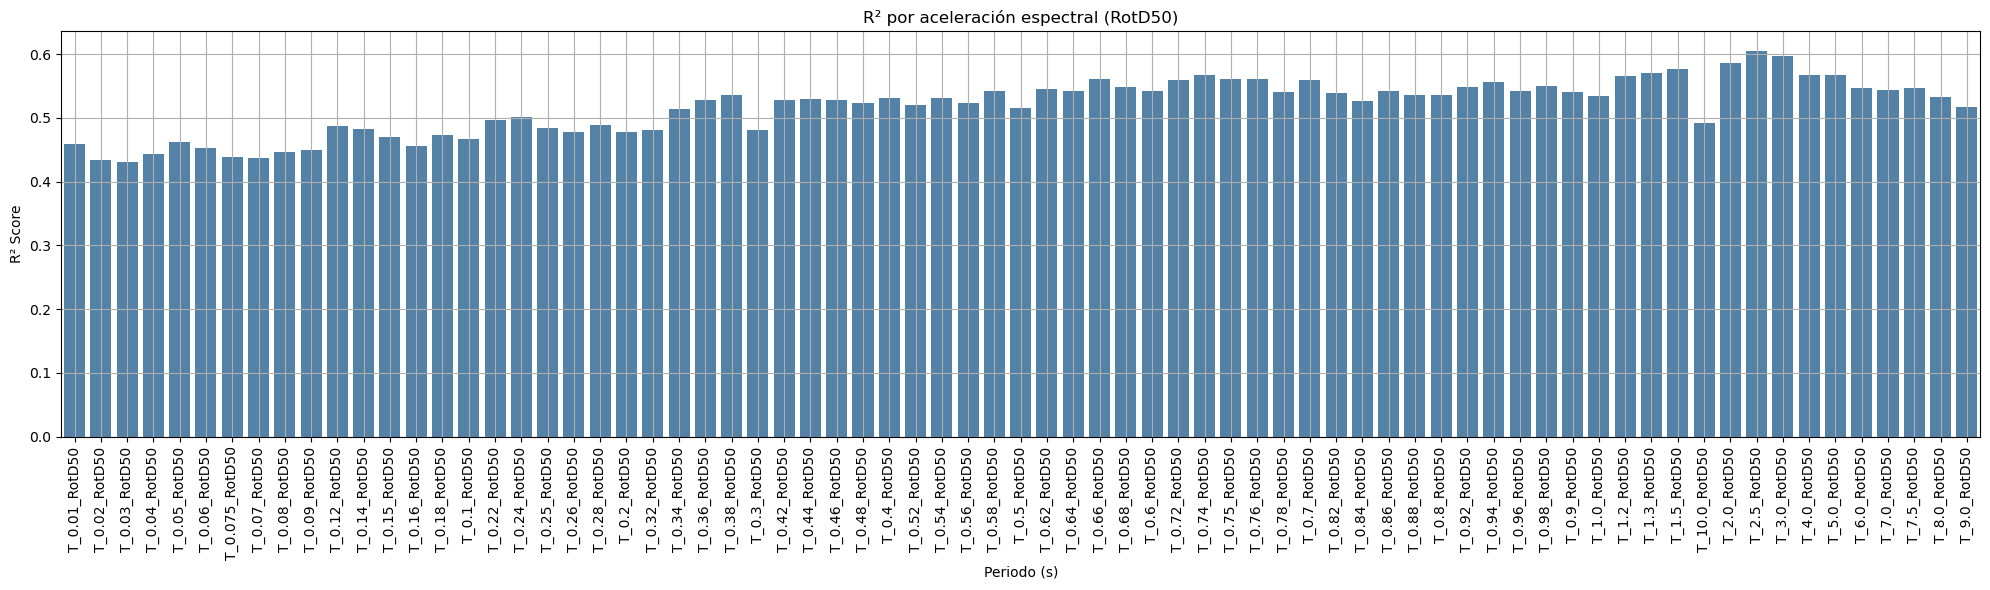

In [29]:

plt.figure(figsize=(20, 6))
sns.barplot(data=r2_df_sorted, x='Sa', y='R²', color='steelblue')
plt.xticks(rotation=90)
plt.title("R² por aceleración espectral (RotD50)")
plt.xlabel("Periodo (s)")
plt.ylabel("R² Score")
plt.grid(True)
plt.tight_layout()
plt.show()


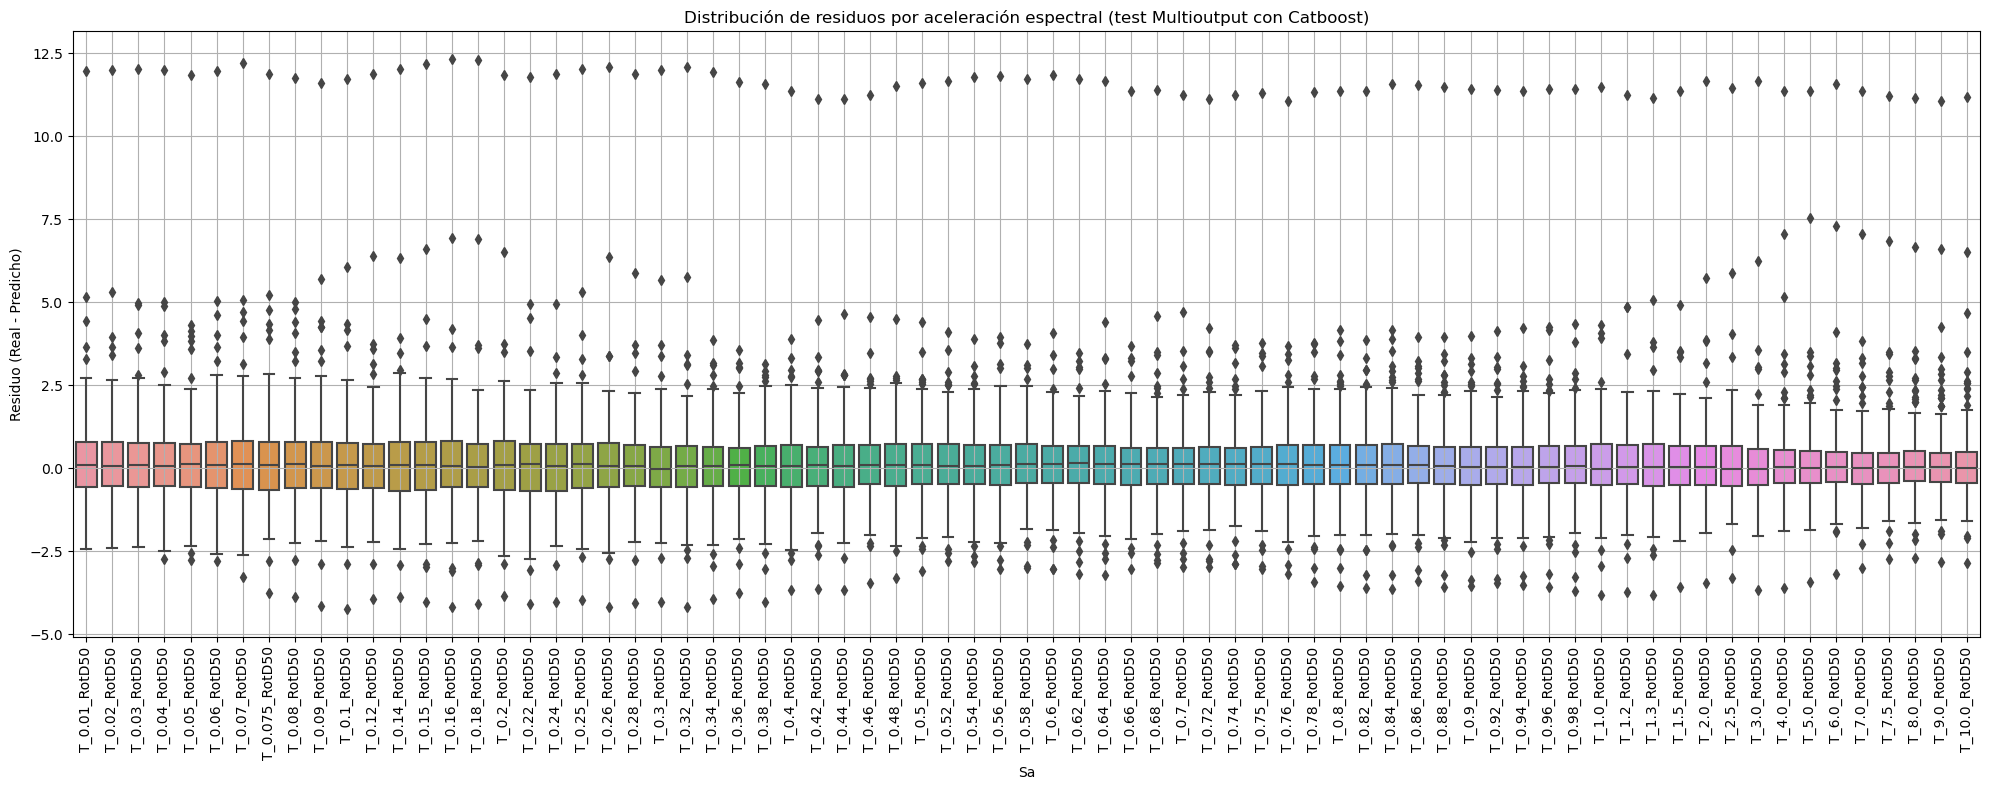

In [30]:
residuos = y_test_Crustal - y_pred_Crustal  # matriz de residuos

df_residuos_crustal = pd.DataFrame(residuos, columns=Sa_Crustal)

df_residuos_largo_crustal = df_residuos_crustal.melt(var_name='Sa', value_name='Residuo')

# Graficar
plt.figure(figsize=(20, 8))
sns.boxplot(data=df_residuos_largo_crustal, x='Sa', y='Residuo')
plt.title("Distribución de residuos por aceleración espectral (test Multioutput con Catboost)")
plt.xticks(rotation=90)
plt.xlabel("Sa")
plt.ylabel("Residuo (Real - Predicho)")
plt.grid(True)
plt.tight_layout()
plt.show()


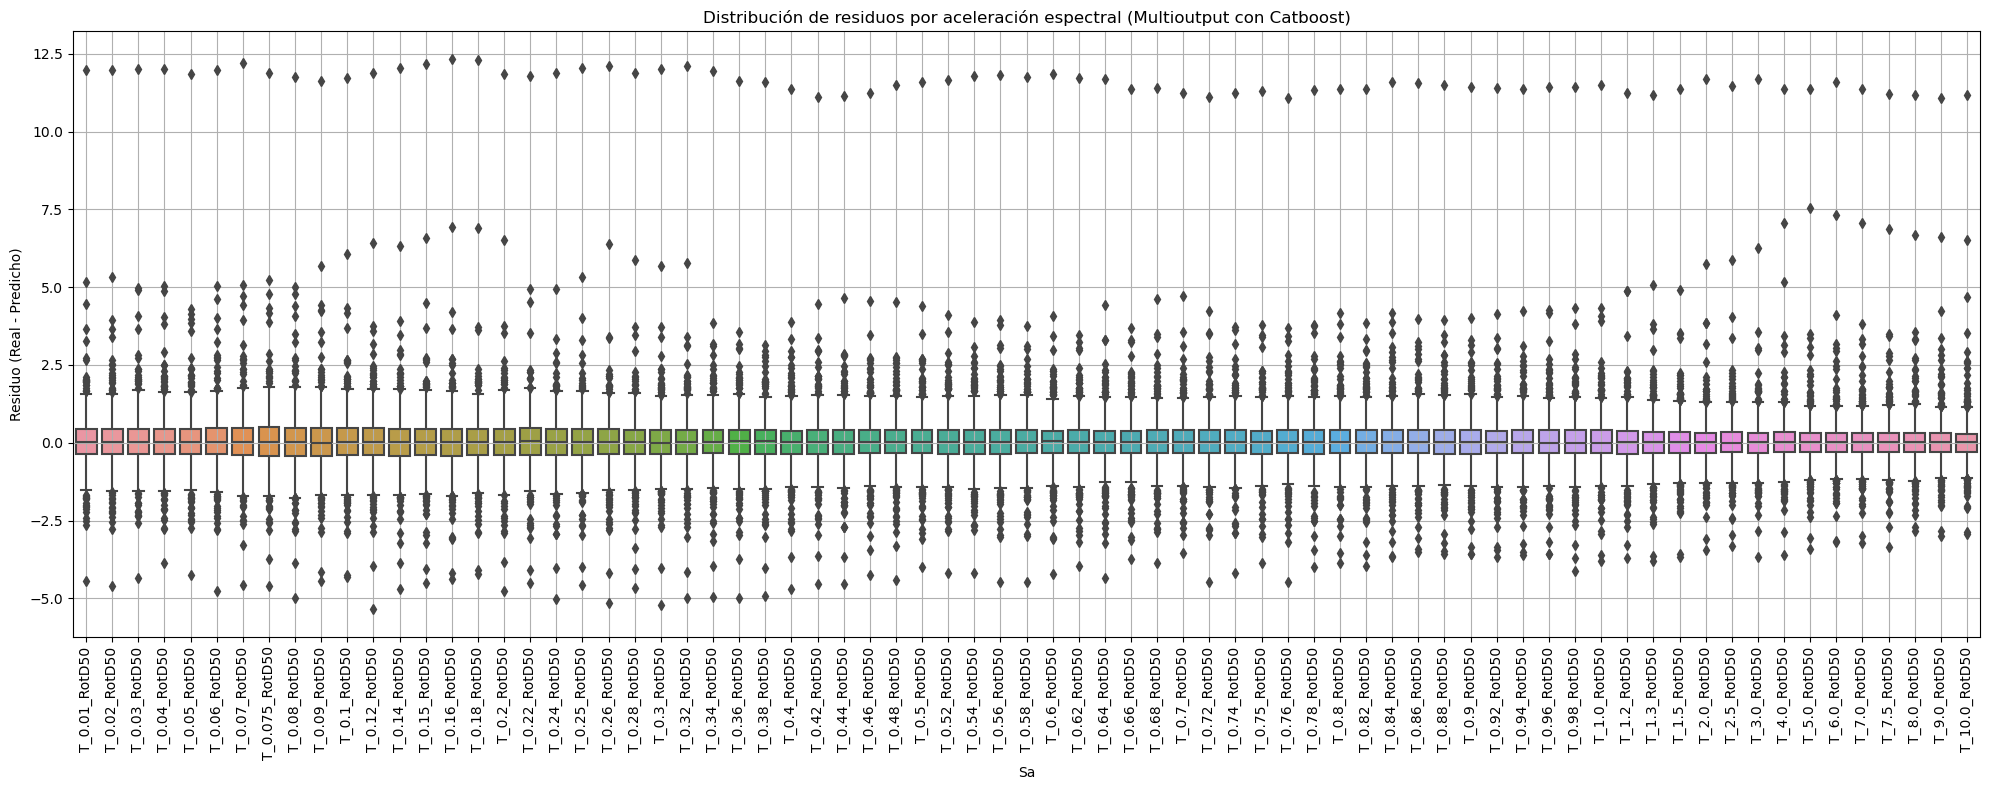

In [31]:
residuos_todos_crustal = Y_Crustal - y_pred_todo_Crustal  # matriz de residuos

df_residuos_crustal_todos = pd.DataFrame(residuos_todos_crustal, columns=Sa_Crustal)

df_residuos_largo_crustal = df_residuos_crustal_todos.melt(var_name='Sa', value_name='Residuo')

# Graficar
plt.figure(figsize=(20, 8))
sns.boxplot(data=df_residuos_largo_crustal, x='Sa', y='Residuo')
plt.title("Distribución de residuos por aceleración espectral (Multioutput con Catboost)")
plt.xticks(rotation=90)
plt.xlabel("Sa")
plt.ylabel("Residuo (Real - Predicho)")
plt.grid(True)
plt.tight_layout()
plt.show()

In [32]:
df_residuos_crustal_todos.describe().T

,count,mean,std,min,25%,50%,75%,max
T_0.01_RotD50,973.0,0.051828,0.830533,-4.457769,-0.375473,0.027867,0.430165,11.981913
T_0.02_RotD50,973.0,0.050808,0.834568,-4.618703,-0.366017,0.022005,0.433743,11.988047
T_0.03_RotD50,973.0,0.058504,0.843375,-4.343426,-0.375632,0.036538,0.453781,12.025918
T_0.04_RotD50,973.0,0.056628,0.846237,-3.877917,-0.365770,0.024300,0.439626,12.016138
T_0.05_RotD50,973.0,0.051118,0.847766,-4.252939,-0.353910,0.032818,0.440339,11.857426
...,...,...,...,...,...,...,...,...
T_7.0_RotD50,973.0,0.035610,0.729645,-3.218231,-0.285446,0.016982,0.306243,11.354685
T_7.5_RotD50,973.0,0.040251,0.722436,-3.339020,-0.299570,0.024018,0.308556,11.204772
T_8.0_RotD50,973.0,0.042599,0.727663,-2.845462,-0.300507,0.025400,0.318012,11.162872
T_9.0_RotD50,973.0,0.038829,0.721902,-3.000221,-0.283347,0.011463,0.301946,11.064346


In [33]:
sismo_df = pd.DataFrame([
    {'Hypocenter Depth (km)': 10, 'Magnitude': 4.5,'Tn':0.2, 'Rrup_OpenQuake': np.log(20)},
    {'Hypocenter Depth (km)': 10, 'Magnitude': 5.5,'Tn':0.2, 'Rrup_OpenQuake': np.log(20)},
    {'Hypocenter Depth (km)': 10, 'Magnitude': 6.5,'Tn':0.2, 'Rrup_OpenQuake': np.log(20)},
    {'Hypocenter Depth (km)': 10, 'Magnitude': 7.5,'Tn':0.2, 'Rrup_OpenQuake': np.log(20)}
])

In [34]:
prediccion = modelo_crustal.predict(sismo_df)  # shape: (4, 22)



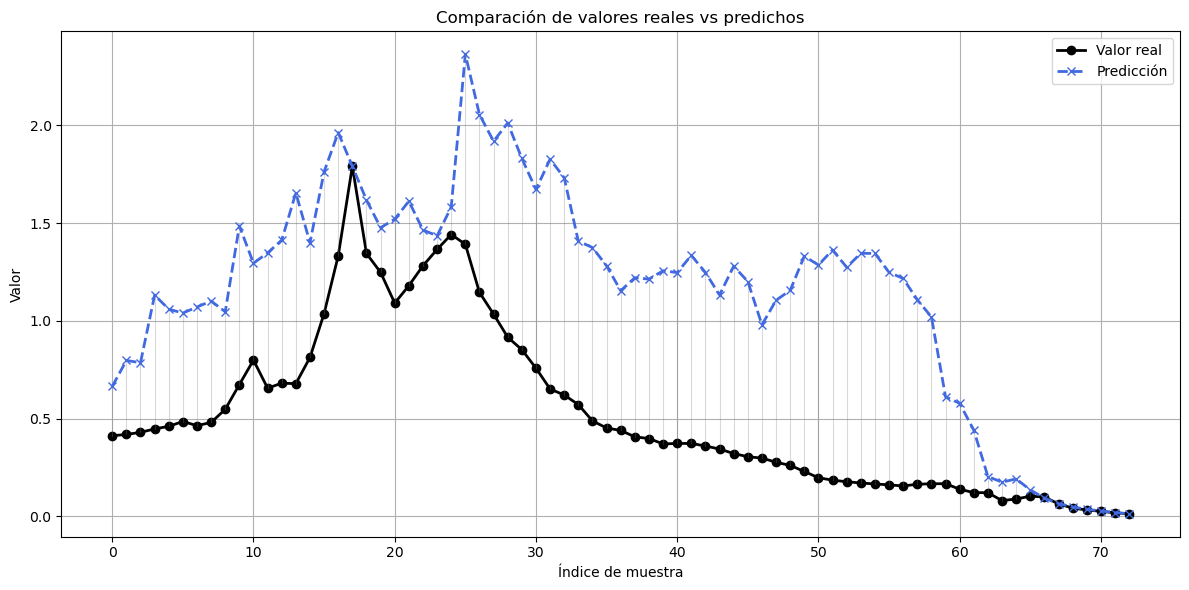

In [35]:
import matplotlib.pyplot as plt
import numpy as np

test_crustal = np.array(np.exp(y_test_Crustal[00]))
pred_crustal = np.array(np.exp(y_pred_Crustal[00]))

plt.figure(figsize=(12, 6))

plt.plot(test_crustal, label='Valor real', color='black', linewidth=2, marker='o')

plt.plot(pred_crustal, label='Predicción', color='royalblue', linewidth=2, linestyle='--', marker='x')

for i in range(len(test_crustal)):
    plt.plot([i, i], [test_crustal[i], pred_crustal[i]], color='gray', alpha=0.3, linewidth=0.8)

plt.title('Comparación de valores reales vs predichos')
plt.xlabel('Índice de muestra')
plt.ylabel('Valor')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


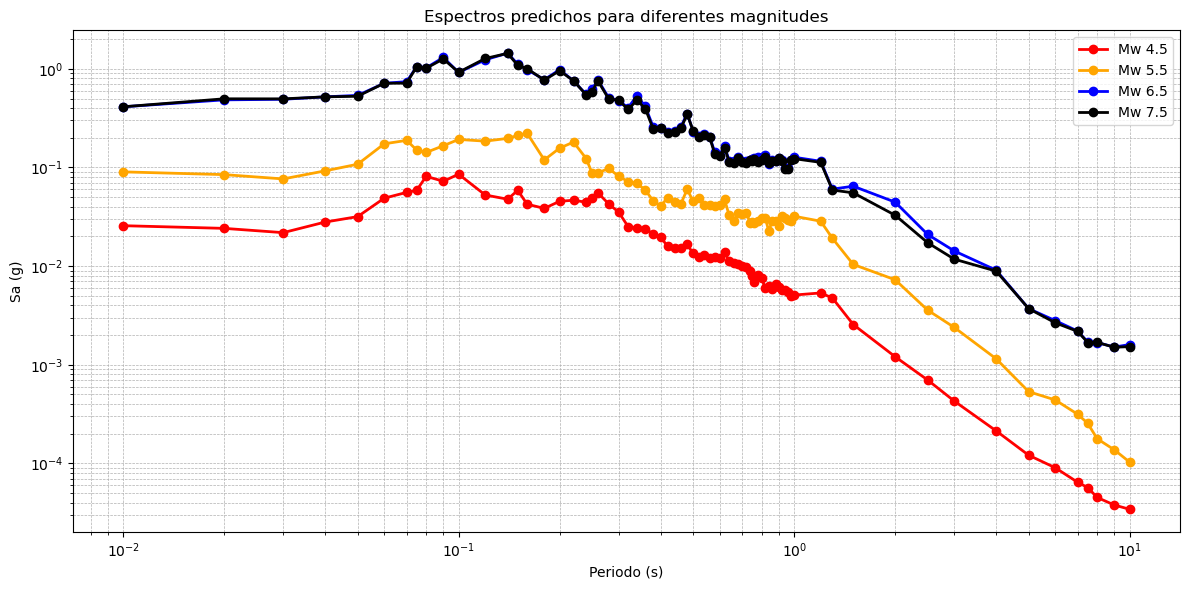

In [36]:
x_periodos = [float(col.split('_')[1]) for col in Sa_Crustal]
Sa_predichos = np.exp(prediccion) / 980  # shape: (4, 22)
test_crustal1 = np.array(np.exp(y_test_Crustal[2])/980)
pred_crustal1= np.array(np.exp(y_pred_Crustal[2])/980)

plt.figure(figsize=(12, 6))

plt.plot(x_periodos, Sa_predichos[0], label='Mw 4.5', color='red', linewidth=2, marker='o')
plt.plot(x_periodos, Sa_predichos[1], label='Mw 5.5', color='orange', linewidth=2, marker='o')
plt.plot(x_periodos, Sa_predichos[2], label='Mw 6.5', color='blue', linewidth=2, marker='o')
plt.plot(x_periodos, Sa_predichos[3], label='Mw 7.5', color='black', linewidth=2, marker='o')

plt.title('Espectros predichos para diferentes magnitudes')
plt.xlabel('Periodo (s)')
plt.ylabel('Sa (g)')
plt.xscale('log')
plt.yscale('log')
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.legend()
plt.tight_layout()
plt.show()


In [37]:
df_residuos_crustal.describe().T

,count,mean,std,min,25%,50%,75%,max
T_0.01_RotD50,292.0,0.176018,1.251484,-2.424085,-0.551071,0.092447,0.781951,11.981913
T_0.02_RotD50,292.0,0.173030,1.257704,-2.387584,-0.528047,0.064077,0.781752,11.988047
T_0.03_RotD50,292.0,0.197277,1.272886,-2.361076,-0.553346,0.106604,0.761116,12.025918
T_0.04_RotD50,292.0,0.190738,1.279535,-2.746127,-0.539407,0.056874,0.765297,12.016138
T_0.05_RotD50,292.0,0.172570,1.273119,-2.750221,-0.551522,0.119794,0.734791,11.857426
...,...,...,...,...,...,...,...,...
T_7.0_RotD50,292.0,0.120486,1.141482,-2.992518,-0.469694,0.012601,0.464892,11.354685
T_7.5_RotD50,292.0,0.137028,1.121965,-2.722807,-0.440021,0.042752,0.474274,11.204772
T_8.0_RotD50,292.0,0.144489,1.128795,-2.714497,-0.396492,0.052994,0.511922,11.162872
T_9.0_RotD50,292.0,0.131957,1.127973,-2.830464,-0.409802,0.037773,0.455206,11.064346


### Crustal con Redes Neuronales

In [38]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [39]:
# Escalado
scaler_X = StandardScaler()
scaler_Y = StandardScaler()

X_scaled = scaler_X.fit_transform(X_Crustal)
Y_scaled = scaler_Y.fit_transform(Y_Crustal)

X_train_neural, X_test_neural, Y_train_neural, Y_test_neural = train_test_split(X_scaled, Y_scaled, test_size=0.3, random_state=0)

"""# 1. Separar primero
X_train_neural, X_test_neural, Y_train_neural, Y_test_neural = train_test_split(
    X_Crustal, Y_Crustal, test_size=0.1, random_state=0
)

# 2. Escalado solo con entrenamiento
scaler_X = StandardScaler()
scaler_Y = StandardScaler()

X_train_neural = scaler_X.fit_transform(X_train_neural)
X_test_neural = scaler_X.transform(X_test_neural)

Y_train_neural = scaler_Y.fit_transform(Y_train_neural)
Y_test_neural = scaler_Y.transform(Y_test_neural)"""


'# 1. Separar primero\nX_train_neural, X_test_neural, Y_train_neural, Y_test_neural = train_test_split(\n    X_Crustal, Y_Crustal, test_size=0.1, random_state=0\n)\n\n# 2. Escalado solo con entrenamiento\nscaler_X = StandardScaler()\nscaler_Y = StandardScaler()\n\nX_train_neural = scaler_X.fit_transform(X_train_neural)\nX_test_neural = scaler_X.transform(X_test_neural)\n\nY_train_neural = scaler_Y.fit_transform(Y_train_neural)\nY_test_neural = scaler_Y.transform(Y_test_neural)'

In [40]:
# Construcción del modelo
model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_neural.shape[1],)),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dense(Y_train_neural.shape[1])  # Tantas salidas como periodos de Sa
])

model.compile(optimizer='adam', loss='mse', metrics=['mae'])

# Entrenamiento
history = model.fit(
    X_train_neural, Y_train_neural,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)],
    verbose=1
)


Epoch 1/100
17/17 [==============================] - 2s 14ms/step - loss: 0.9769 - mae: 0.7547 - val_loss: 1.2704 - val_mae: 0.7533
Epoch 2/100
17/17 [==============================] - 0s 4ms/step - loss: 0.8448 - mae: 0.6907 - val_loss: 1.1540 - val_mae: 0.6765
Epoch 3/100
17/17 [==============================] - 0s 5ms/step - loss: 0.6679 - mae: 0.5921 - val_loss: 1.0528 - val_mae: 0.5841
Epoch 4/100
17/17 [==============================] - 0s 4ms/step - loss: 0.5572 - mae: 0.5222 - val_loss: 1.0483 - val_mae: 0.5551
Epoch 5/100
17/17 [==============================] - 0s 4ms/step - loss: 0.5241 - mae: 0.4980 - val_loss: 1.0277 - val_mae: 0.5445
Epoch 6/100
17/17 [==============================] - 0s 4ms/step - loss: 0.4934 - mae: 0.4856 - val_loss: 1.0303 - val_mae: 0.5451
Epoch 7/100
17/17 [==============================] - 0s 4ms/step - loss: 0.4901 - mae: 0.4775 - val_loss: 1.0251 - val_mae: 0.5385
Epoch 8/100
17/17 [==============================] - 0s 4ms/step - loss: 0.4828 - 

In [41]:
# Evaluación en test
loss, mae = model.evaluate(X_test_neural, Y_test_neural)
print(f"MSE: {loss:.4f} - MAE: {mae:.4f}")

# Predicción
Y_pred_scaled = model.predict(X_test_neural)
Y_pred_scaled_train = model.predict(X_train_neural)
# Inversión del escalado
Y_pred_neural = scaler_Y.inverse_transform(Y_pred_scaled)
Y_true_neural = scaler_Y.inverse_transform(Y_test_neural)
Y_train_true_neural = scaler_Y.inverse_transform(Y_train_neural)
Y_train_pred_neural = scaler_Y.inverse_transform(Y_pred_scaled_train)


10/10 [==============================] - 0s 2ms/step - loss: 0.3217 - mae: 0.4443
MSE: 0.3217 - MAE: 0.4443
22/22 [==============================] - 0s 1ms/step


<Figure size 1400x1200 with 0 Axes>

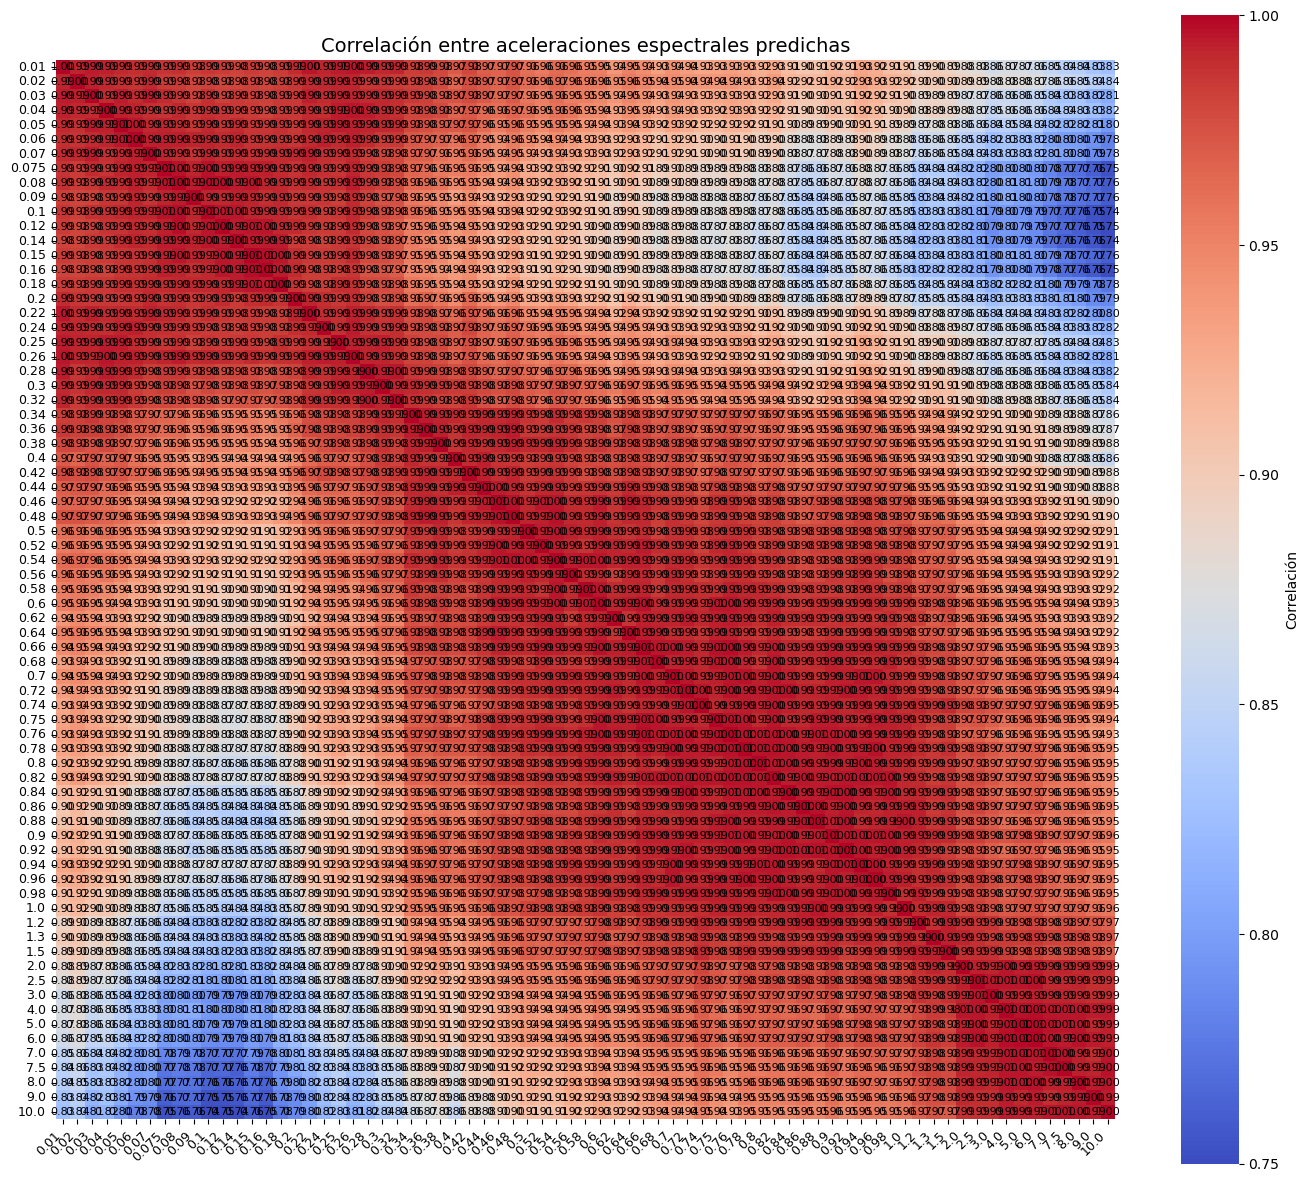

In [42]:

labels = [s.split('_')[1] for s in Sa_Crustal]  # ['0.01', '0.02', ..., '10.0']

# Calcular la matriz de correlación
corr_matrix = np.corrcoef(Y_pred_neural.T)
plt.figure(figsize=(14, 12))


fig, ax = plt.subplots(figsize=(14, 12))

sns.heatmap(
    corr_matrix,
    xticklabels=labels,
    yticklabels=labels,
    cmap='coolwarm',
    vmin=0.75,
    vmax=1.0,
    square=True,
    cbar_kws={'label': 'Correlación'},
    ax=ax
)

for i in range(corr_matrix.shape[0]):
    for j in range(corr_matrix.shape[1]):
        value = corr_matrix[i, j]
        ax.text(
            j + 0.5, i + 0.5,          
            f"{value:.2f}",               
            ha='center', va='center',
            fontsize=8, color='black'
        )

ax.set_title('Correlación entre aceleraciones espectrales predichas', fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(rotation=0, fontsize=9)
plt.tight_layout()
plt.show()



In [43]:
# R² del conjunto de test
y_test_df_neural = pd.DataFrame(Y_true_neural, columns=Sa_Crustal)
y_pred_df_neural = pd.DataFrame(Y_pred_neural, columns=Sa_Crustal)
r2_por_periodo_neural_test = {
    col: r2_score(y_test_df_neural[col], y_pred_df_neural[col])
    for col in Sa_Crustal
}
r2_test_df = pd.DataFrame.from_dict(r2_por_periodo_neural_test, orient='index', columns=['R² test'])
r2_test_df.index.name = "Sa"
r2_test_df.reset_index(inplace=True)

# R² del conjunto de entrenamiento
y_train_df_neural = pd.DataFrame(Y_train_true_neural, columns=Sa_Crustal)
y_pred_train_df_neural = pd.DataFrame(Y_train_pred_neural, columns=Sa_Crustal)
r2_por_periodo_neural_train = {
    col: r2_score(y_train_df_neural[col], y_pred_train_df_neural[col])
    for col in Sa_Crustal
}
r2_train_df = pd.DataFrame.from_dict(r2_por_periodo_neural_train, orient='index', columns=['R² train'])
r2_train_df.index.name = "Sa"
r2_train_df.reset_index(inplace=True)

# Unión de ambos DataFrames
r2_completo = pd.merge(r2_train_df, r2_test_df, on='Sa')
display(r2_completo)


,Sa,R² train,R² test
0,T_0.01_RotD50,0.449771,0.590367
1,T_0.02_RotD50,0.440317,0.578106
2,T_0.03_RotD50,0.440209,0.572996
3,T_0.04_RotD50,0.441200,0.576437
4,T_0.05_RotD50,0.438182,0.569223
...,...,...,...
68,T_7.0_RotD50,0.581329,0.706315
69,T_7.5_RotD50,0.580419,0.704751
70,T_8.0_RotD50,0.576431,0.721491
71,T_9.0_RotD50,0.570729,0.718038


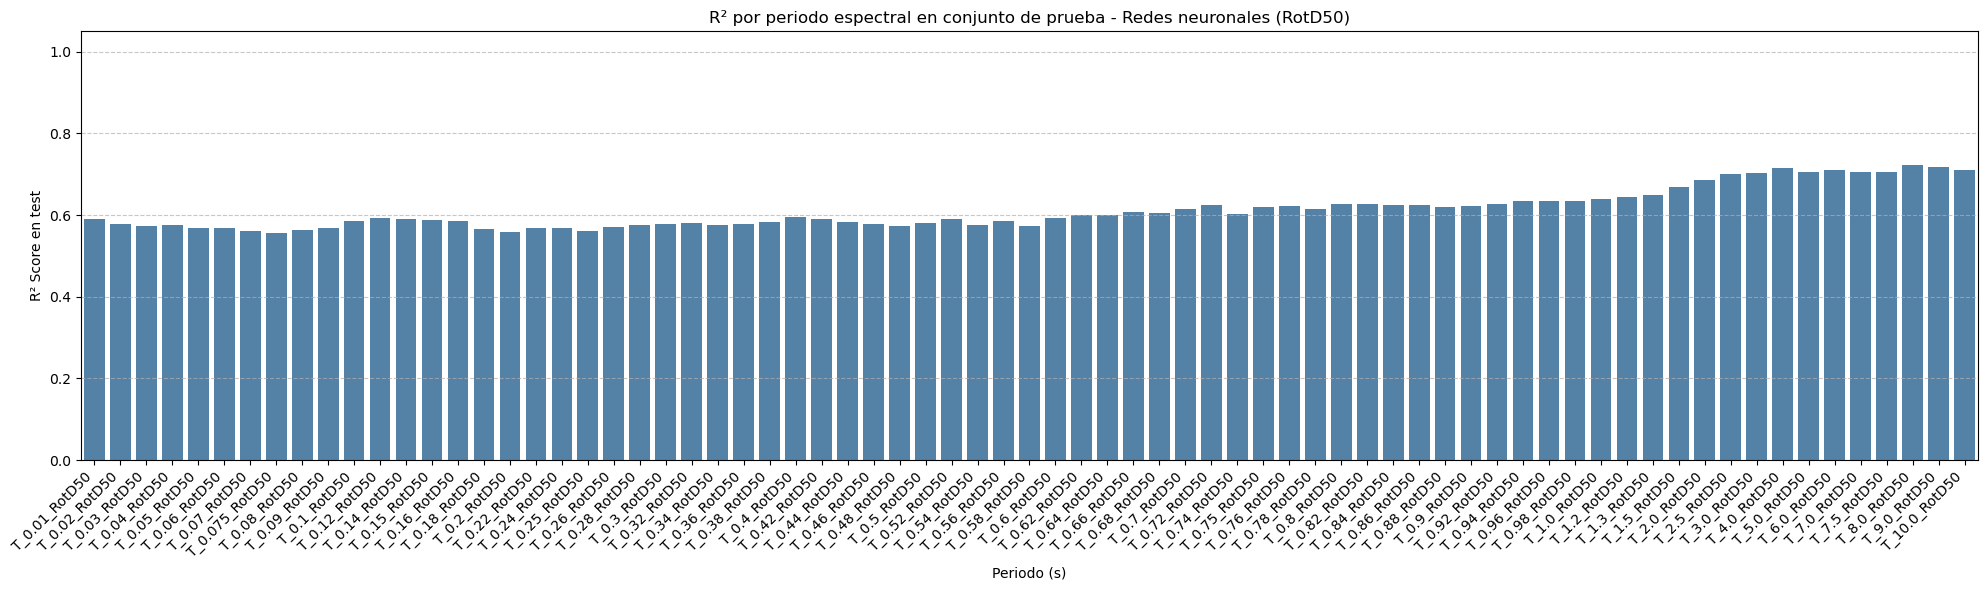

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(20, 6))
sns.barplot(data=r2_completo, x='Sa', y='R² test', color='steelblue')

# Ajuste estético
plt.xticks(rotation=45, ha='right')
plt.title("R² por periodo espectral en conjunto de prueba - Redes neuronales (RotD50)")
plt.xlabel("Periodo (s)")
plt.ylabel("R² Score en test")
plt.ylim(0, 1.05)  # Ajuste de escala para R²
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


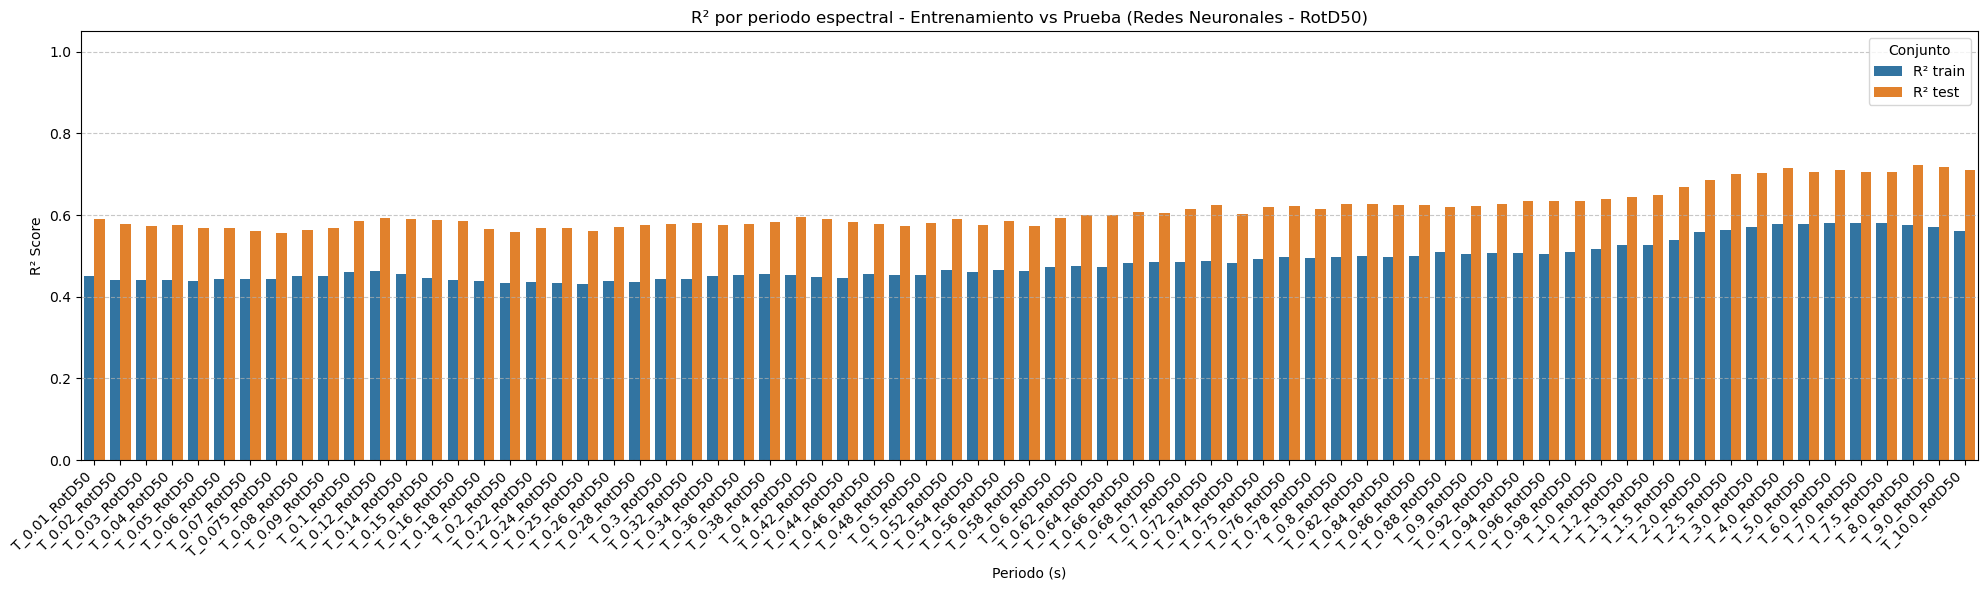

In [45]:
r2_long = pd.melt(r2_completo, id_vars='Sa', value_vars=['R² train', 'R² test'],
                  var_name='Conjunto', value_name='R²')

# Gráfico de barras agrupadas
plt.figure(figsize=(20, 6))
sns.barplot(data=r2_long, x='Sa', y='R²', hue='Conjunto')

plt.xticks(rotation=45, ha='right')
plt.title("R² por periodo espectral - Entrenamiento vs Prueba (Redes Neuronales - RotD50)")
plt.xlabel("Periodo (s)")
plt.ylabel("R² Score")
plt.ylim(0, 1.05)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Conjunto')
plt.tight_layout()
plt.show()


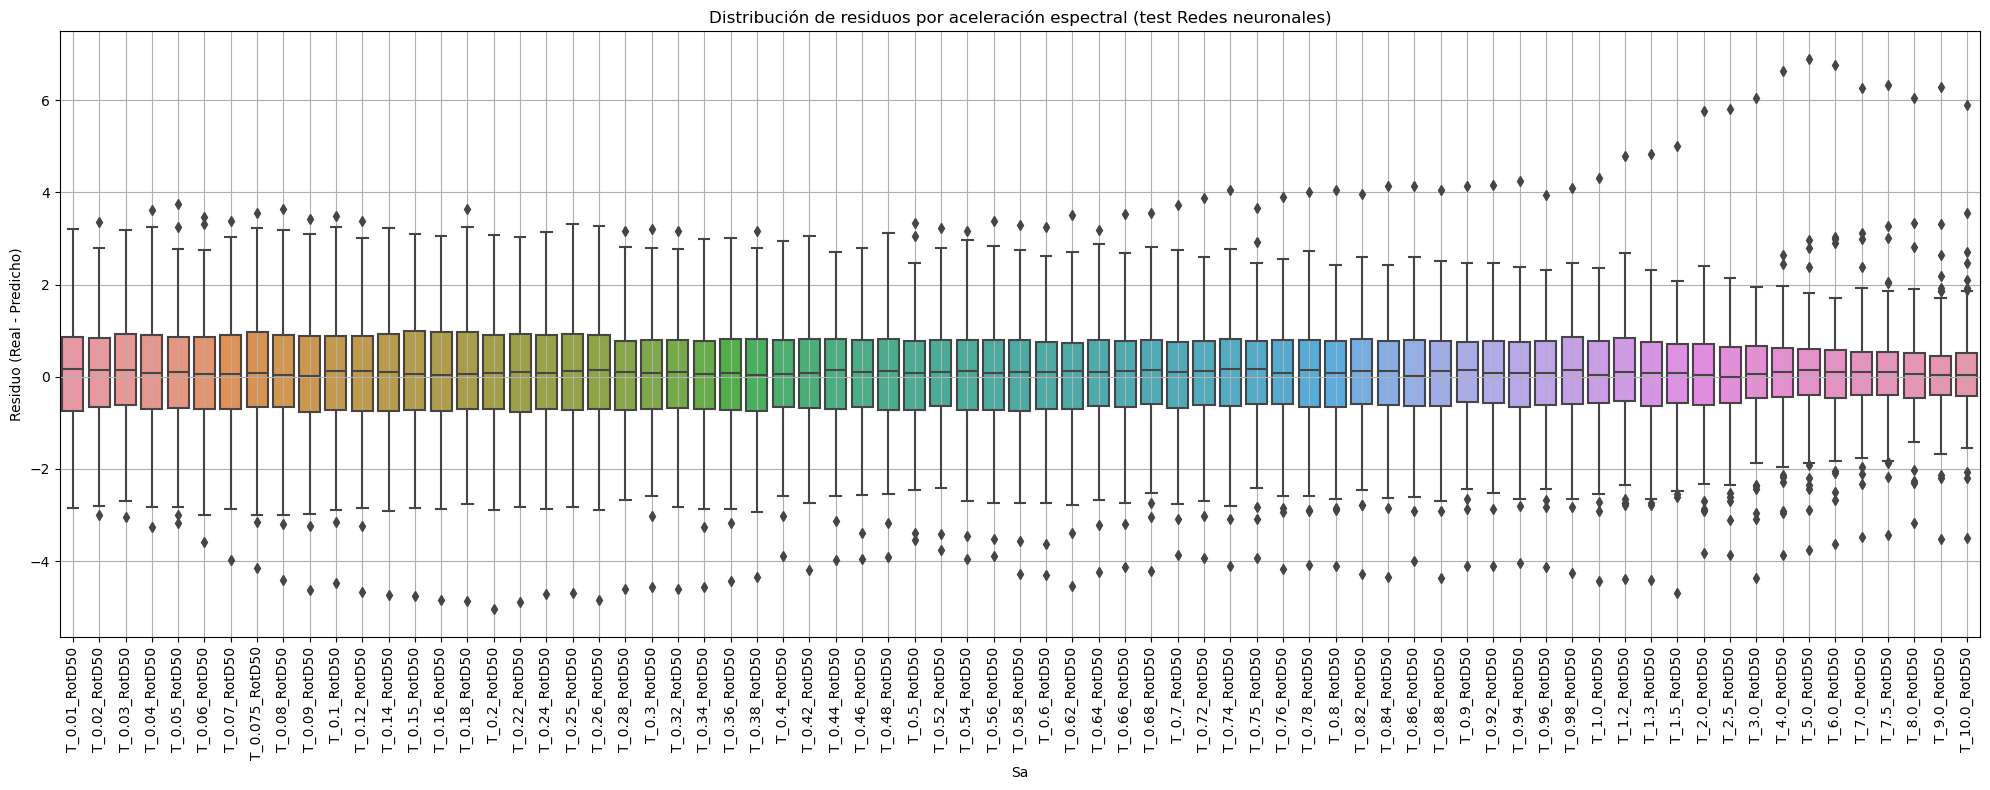

In [46]:
residuos_neural = Y_true_neural - Y_pred_neural  # matriz de residuos

df_residuos_crustal_neural = pd.DataFrame(residuos_neural, columns=Sa_Crustal)

df_residuos_largo_crustal_neural = df_residuos_crustal_neural.melt(var_name='Sa', value_name='Residuo')

# Graficar
plt.figure(figsize=(20, 8))
sns.boxplot(data=df_residuos_largo_crustal_neural, x='Sa', y='Residuo')
plt.title("Distribución de residuos por aceleración espectral (test Redes neuronales)")
plt.xticks(rotation=90)
plt.xlabel("Sa")
plt.ylabel("Residuo (Real - Predicho)")
plt.grid(True)
plt.tight_layout()
plt.show()


In [47]:
# Cada fila es [Hypocenter Depth (km), Magnitude, Tn, Rrup_OpenQuake]
X_nuevos = np.array([
    [10, 4.5, 0.2,np.log(20)],
    [10, 5.5, 0.2,np.log(20)],
    [10, 6.5, 0.2,np.log(20)],
    [10, 7.5, 0.2,np.log(20)]
])  # shape: (4, 4)


In [48]:
X_nuevos_scaled = scaler_X.transform(X_nuevos)
Y_pred_scaled = model.predict(X_nuevos_scaled)
Y_pred_log = scaler_Y.inverse_transform(Y_pred_scaled)
Y_pred = np.exp(Y_pred_log) / 980

1/1 [==============================] - 0s 36ms/step


In [49]:
# Periodos (s)
x_vals = [
[
    0.010875285775728515, 0.020311081595293035, 0.03871896403583624,
    0.0657349913573477, 0.1095248612988198, 0.16220474678481317,
    0.2485678267476934, 0.39462667718357053, 0.68853136522965,
    1.1547819846894594, 1.7261410118050462, 3.0109783106598242,
    4.512831857425389, 6.243741513173544, 9.500670085088025
],[
    0.010936468808161997, 0.021672600071547247, 0.03975249638696299,
    0.0674567515926146, 0.11242100350620886, 0.1696918627096272,
    0.2550162156074561, 0.4376245678535534, 0.7089826268593195,
    1.1928586468756044, 1.8928606549514229, 3.2458970840552537,
    4.767425315612845, 6.600813428549337, 9.685518641874227
],
[0.011225659486328633, 0.020970566828998064, 0.0392036290496946,
    0.06786935608502156, 0.1153093188707811, 0.1775245721265105,
    0.2615042873866538, 0.4494157672476691, 0.7291515387072267,
    1.2534101877616912, 2.031108159529296, 3.5541972411039024,
    5.125612412646484, 7.105407385250373, 9.83790314035472],
[
    0.011299833228879636, 0.0211091302182597, 0.03945304324066873,
    0.06833447001801594, 0.11612786474052615, 0.17869756886005894,
    0.2738419634264367, 0.4528268847291676, 0.7795486438226266,
    1.341350800816033, 2.26287735787004, 3.737348177498041,
    5.389739766669773, 7.761335205956115, 10.34738261954024
]]

# Aceleración espectral (Sa) en g
y_vals = [[
    0.026607250597988127, 0.02738419634264363, 0.03162277660168381,
    0.042169650342858245, 0.061305579214982114, 0.08175230379436497,
    0.061305579214982114, 0.029853826189179616, 0.010000000000000005,
    0.003162277660168386, 0.0012589254117941688, 0.00040973210981354216,
    0.0002238721138568347, 0.00009716279515771078, 0.000031622776601683856
],[
    0.051582216507230584, 0.05787619883491206, 0.07079457843841384,
    0.08912509381337463, 0.13335214321633246, 0.16788040181225597,
    0.1258925411794168, 0.05956621435290106, 0.03162277660168381,
    0.014537843856076644, 0.006683439175686149, 0.002900681198693156,
    0.0014537843856076637, 0.0006878599123088081, 0.0003072557365267452
],[0.11220184543019647, 0.11885022274370183, 0.1372460961007562,
    0.18302061063110578, 0.26607250597988097, 0.34474660657314926,
    0.244061906804198, 0.1372460961007562, 0.08659643233600658,
    0.050118723362727276, 0.02738419634264363, 0.01295686697517021,
    0.0074989420933245735, 0.004097321098135422, 0.0019386526359522096],
[
    0.244061906804198, 0.25852348395621927, 0.29006811986931547,
    0.4097321098135415, 0.6130557921498209, 0.7498942093324559,
    0.5623413251903494, 0.3349654391578278, 0.23040929760558482,
    0.14962356560944334, 0.0944060876285924, 0.04869675251658634,
    0.028183829312644536, 0.013724609610075633, 0.0074989420933245735
],]


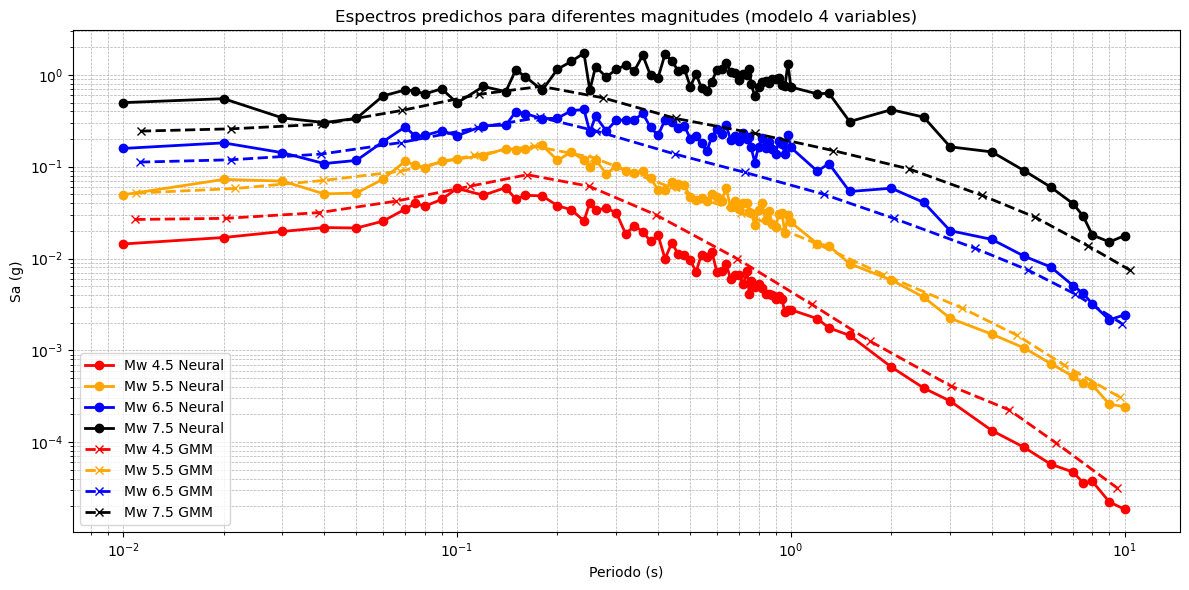

In [50]:
x_periodos = [float(col.split('_')[1]) for col in Sa_Crustal]

# Configuración del gráfico
plt.figure(figsize=(12, 6))
labels = ['Mw 4.5', 'Mw 5.5', 'Mw 6.5', 'Mw 7.5']
colors = ['red', 'orange', 'blue', 'black']

for i in range(4):
    plt.plot(x_periodos, Y_pred[i], label=f'{labels[i]} Neural', color=colors[i], marker='o', linewidth=2)
for i in range(4):
    plt.plot(x_vals[i], y_vals[i], label=f'{labels[i]} GMM', color=colors[i], linestyle='--', marker='x', linewidth=2)
    
plt.title('Espectros predichos para diferentes magnitudes (modelo 4 variables)')
plt.xlabel('Periodo (s)')
plt.ylabel('Sa (g)')
plt.xscale('log')
plt.yscale('log')
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.legend()
plt.tight_layout()
plt.show()



In [51]:
n =18
print(scaler_X.inverse_transform(X_test_neural[n].reshape(1, -1)))
xreal = scaler_X.inverse_transform(X_test_neural[n].reshape(1, -1))
xreal[0][3]=np.exp(xreal[0][3])
print(xreal)

[[27.          4.7         0.1         4.76217636]]
[[2.70000000e+01 4.70000000e+00 1.00000000e-01 1.17000284e+02]]


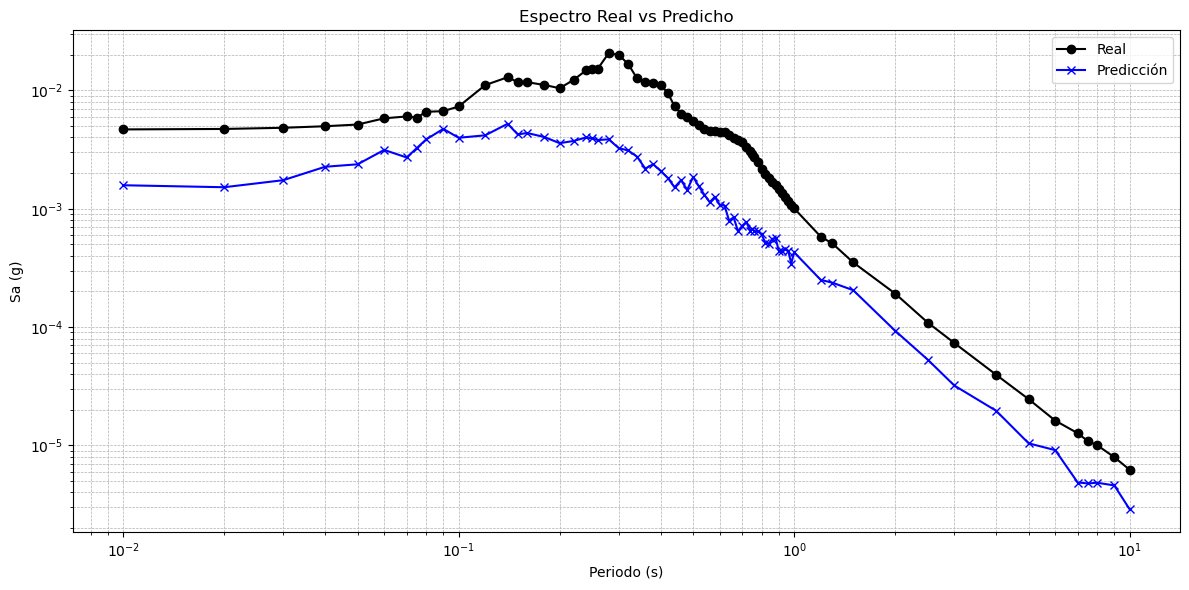

In [52]:
x_periodos = [float(col.split('_')[1]) for col in Sa_Crustal]

# Convertimos de log(Sa) a Sa real (asumiendo log natural) y luego a g dividiendo por 980
test_crustal_neural = np.exp(Y_true_neural) / 980
pred_crustal_neural = np.exp(Y_pred_neural) / 980

# Comparamos Mw 6.5, que según tu orden es el índice 2
plt.figure(figsize=(12, 6))
plt.plot(x_periodos, test_crustal_neural[n], label='Real', color='black', marker='o')
plt.plot(x_periodos, pred_crustal_neural[n], label='Predicción', color='blue', marker='x')

plt.title('Espectro Real vs Predicho')
plt.xlabel('Periodo (s)')
plt.ylabel('Sa (g)')
plt.xscale('log')
plt.yscale('log')
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.legend()
plt.tight_layout()
plt.show()

### Subduction